In [1]:
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/train.csv
/kaggle/input/description.md
/kaggle/input/sample_submission.csv.zip
/kaggle/input/test.csv.zip
/kaggle/input/train.csv.zip
/kaggle/input/test.csv
/kaggle/input/sample_submission.csv
/kaggle/input/playground-series-s3e18/train.csv
/kaggle/input/playground-series-s3e18/description.md
/kaggle/input/playground-series-s3e18/sample_submission.csv.zip
/kaggle/input/playground-series-s3e18/test.csv.zip
/kaggle/input/playground-series-s3e18/train.csv.zip
/kaggle/input/playground-series-s3e18/test.csv
/kaggle/input/playground-series-s3e18/sample_submission.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler


def _simple_data_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    """
    Minimal, score-neutral cleaning to replace klib.data_cleaning:
    - copy
    - replace +/-inf with NaN
    - (do not drop rows/cols)
    """
    out = df.copy()
    out = out.replace([np.inf, -np.inf], np.nan)
    return out


def _missingval_plot_stub(df: pd.DataFrame):
    na_rate = df.isna().mean().sort_values(ascending=False)
    print("Top missingness:\n", na_rate.head(10))


def _corr_plot_stub(df: pd.DataFrame):
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] == 0:
        print("No numeric columns for correlation plot.")
        return
    corr = num.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Correlation heatmap (numeric features)")
    plt.show()




In [3]:
df_train = pd.read_csv("/kaggle/input/playground-series-s3e18/train.csv")
df_test = pd.read_csv("/kaggle/input/playground-series-s3e18/test.csv")
sub = pd.read_csv("/kaggle/input/playground-series-s3e18/sample_submission.csv")



In [4]:
try:
    _missingval_plot_stub(df_train)
    _missingval_plot_stub(df_test)
    _missingval_plot_stub(sub)
except Exception as e:
    print("Skipping missing value plots due to:", repr(e))



Top missingness:
 id             0.0
BertzCT        0.0
Chi1           0.0
Chi1n          0.0
Chi1v          0.0
Chi2n          0.0
Chi2v          0.0
Chi3v          0.0
Chi4n          0.0
EState_VSA1    0.0
dtype: float64
Top missingness:
 id             0.0
BertzCT        0.0
Chi1           0.0
Chi1n          0.0
Chi1v          0.0
Chi2n          0.0
Chi2v          0.0
Chi3v          0.0
Chi4n          0.0
EState_VSA1    0.0
dtype: float64
Top missingness:
 id     0.0
EC1    0.0
EC2    0.0
dtype: float64


In [5]:
train_raw = _simple_data_cleaning(df_train)
test_raw = _simple_data_cleaning(df_test)



In [6]:
drop_cols = [c for c in ["EC3", "EC4", "EC5", "EC6"] if c in train_raw.columns]
train_raw = train_raw.drop(drop_cols, axis=1)
train_raw.head()



,id,BertzCT,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3v,Chi4n,EState_VSA1,...,PEOE_VSA7,PEOE_VSA8,SMR_VSA10,SMR_VSA5,SlogP_VSA3,VSA_EState9,fr_COO,fr_COO2,EC1,EC2
0,3305,212.928441,6.270857,3.431698,4.045502,1.811731,2.272429,1.619489,0.828835,7.822697,...,0.000000,12.617665,22.655475,12.462662,13.825658,36.819857,0,0,1,1
1,8217,221.694355,4.060660,3.548618,3.548618,2.499652,2.499652,1.607504,0.883813,17.980451,...,12.132734,0.000000,17.650296,6.420822,9.589074,39.833333,2,2,1,0
2,12616,159.130752,4.414719,2.801636,2.801636,2.676274,2.676274,1.204209,0.361282,12.011146,...,0.000000,0.000000,5.969305,12.462662,11.215359,33.500000,1,1,1,1
3,10153,1239.282494,16.098662,10.151117,10.151117,11.008637,11.008637,7.914542,3.408511,5.969305,...,13.847474,6.420822,11.752550,69.031041,9.589074,73.500000,1,1,1,1
4,9564,574.170559,8.417121,5.143525,5.143525,3.478542,3.478542,2.264463,2.087653,5.969305,...,17.696186,6.076020,5.969305,57.332884,4.794537,39.166667,1,1,1,0


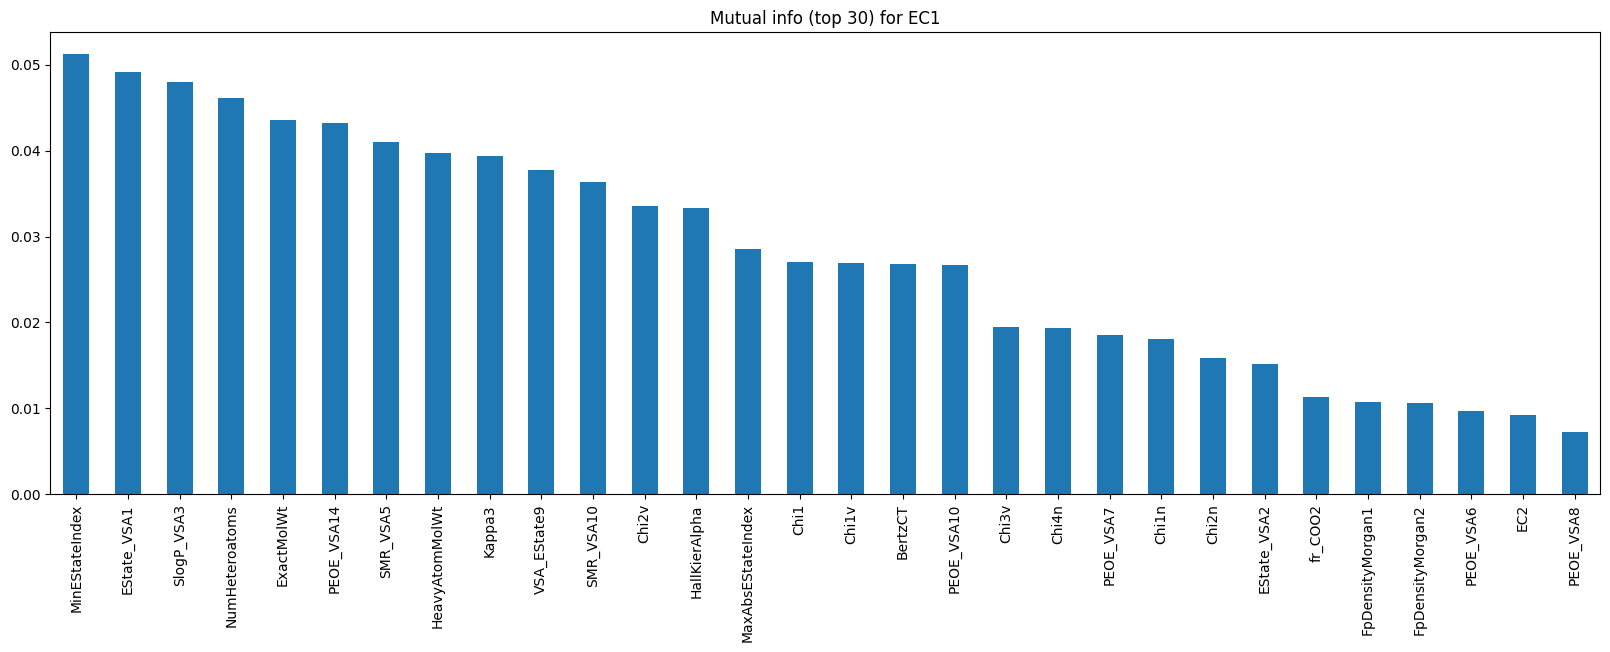

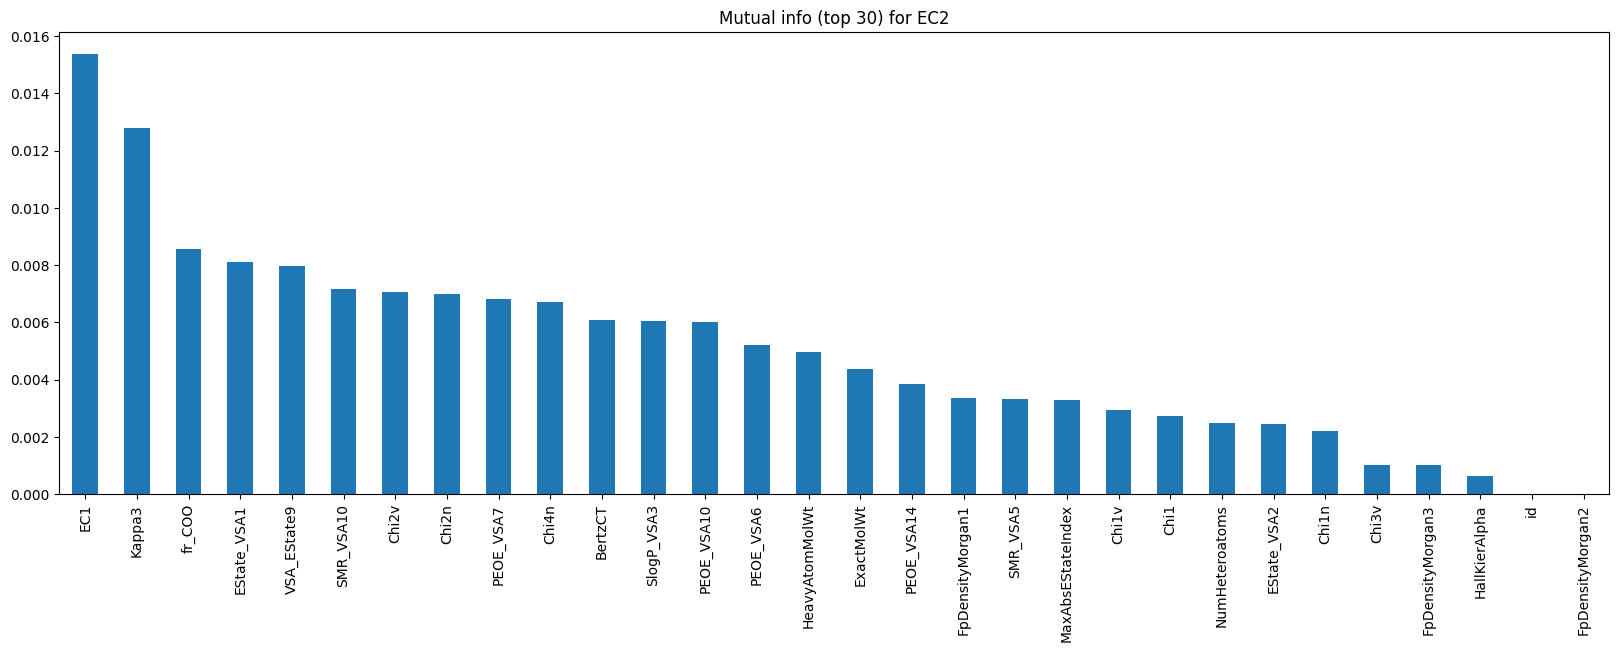

{'EC1': Index(['EState_VSA1', 'ExactMolWt', 'HallKierAlpha', 'HeavyAtomMolWt',
        'MinEStateIndex', 'NumHeteroatoms', 'PEOE_VSA14', 'SMR_VSA10',
        'SlogP_VSA3', 'VSA_EState9'],
       dtype='object'),
 'EC2': Index(['Chi1n', 'Chi2n', 'ExactMolWt', 'HeavyAtomMolWt', 'MaxAbsEStateIndex',
        'MinEStateIndex', 'SlogP_VSA3', 'VSA_EState9', 'fr_COO', 'EC1'],
       dtype='object')}

In [7]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest

target = ["EC1", "EC2"]
dic = {}
for i in target:
    X_tmp = train_raw.drop([i], axis=1)
    y_tmp = train_raw[i]
    X_tmp_num = X_tmp.select_dtypes(include=[np.number]).copy()
    for c in X_tmp_num.columns:
        X_tmp_num[c] = X_tmp_num[c].fillna(X_tmp_num[c].median())
    mutual_info = mutual_info_classif(X_tmp_num, y_tmp)
    mutual_info = pd.Series(mutual_info, index=X_tmp_num.columns).sort_values(
        ascending=False
    )

    try:
        mutual_info.head(30).plot.bar(
            title=f"Mutual info (top 30) for {i}", figsize=(20, 6)
        )
        plt.show()
    except Exception as e:
        print(f"Skipping mutual info plot for {i} due to:", repr(e))

    select_cols = SelectKBest(mutual_info_classif, k=min(10, X_tmp_num.shape[1]))
    select_cols.fit(X_tmp_num, y_tmp)
    dic[i] = X_tmp_num.columns[select_cols.get_support()]
dic



In [8]:
X_tmp = train_raw.drop(["EC1"], axis=1).select_dtypes(include=[np.number]).copy()
for c in X_tmp.columns:
    X_tmp[c] = X_tmp[c].fillna(X_tmp[c].median())
mutual_info = mutual_info_classif(X_tmp, train_raw["EC1"])
mutual_info = pd.Series(mutual_info, index=X_tmp.columns).sort_values(ascending=False)
mutual_info.head(20)



MinEStateIndex       0.053063
EState_VSA1          0.052735
SlogP_VSA3           0.051087
NumHeteroatoms       0.047860
VSA_EState9          0.040099
HeavyAtomMolWt       0.039781
ExactMolWt           0.037099
PEOE_VSA14           0.036956
SMR_VSA10            0.035959
BertzCT              0.032869
Kappa3               0.032790
MaxAbsEStateIndex    0.032465
SMR_VSA5             0.032187
HallKierAlpha        0.031016
Chi1v                0.029991
PEOE_VSA10           0.029226
Chi2v                0.028549
Chi1                 0.023361
Chi1n                0.021692
Chi2n                0.021613
dtype: float64

In [9]:
mutual_info.index[0 : round(len(mutual_info) / 2)]



Index(['MinEStateIndex', 'EState_VSA1', 'SlogP_VSA3', 'NumHeteroatoms',
       'VSA_EState9', 'HeavyAtomMolWt', 'ExactMolWt', 'PEOE_VSA14',
       'SMR_VSA10', 'BertzCT', 'Kappa3', 'MaxAbsEStateIndex', 'SMR_VSA5',
       'HallKierAlpha', 'Chi1v', 'PEOE_VSA10'],
      dtype='object')

In [10]:
test_raw.head()



,id,BertzCT,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3v,Chi4n,EState_VSA1,...,PEOE_VSA14,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,SMR_VSA10,SMR_VSA5,SlogP_VSA3,VSA_EState9,fr_COO,fr_COO2
0,1377,221.263866,7.413591,5.874959,5.874959,2.861666,2.861666,1.786050,1.058931,5.969305,...,5.969305,24.30408,6.076020,5.563451,5.969305,0.000000,11.215359,55.666667,1,1
1,5485,124.934332,6.270857,3.633936,3.633936,2.571553,2.571553,1.539558,0.835261,6.103966,...,91.536492,0.00000,0.000000,0.000000,17.744066,37.629629,4.794537,29.776814,0,0
2,8753,635.074655,8.702709,5.790467,5.790467,4.516427,4.516427,3.710047,2.299833,26.502851,...,0.000000,0.00000,0.000000,0.000000,11.163878,24.539800,4.736863,53.217315,0,0
3,10746,155.036985,4.536581,2.688080,2.688080,1.812046,1.812046,0.835979,0.592466,17.980451,...,11.938611,0.00000,6.420822,0.000000,11.938611,19.386400,9.589074,40.083333,2,2
4,7554,313.333120,7.430428,4.046610,4.451852,2.725738,3.181080,2.093778,1.275017,24.601926,...,0.000000,0.00000,12.132734,0.000000,16.864286,12.207933,4.736863,44.716239,0,0


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


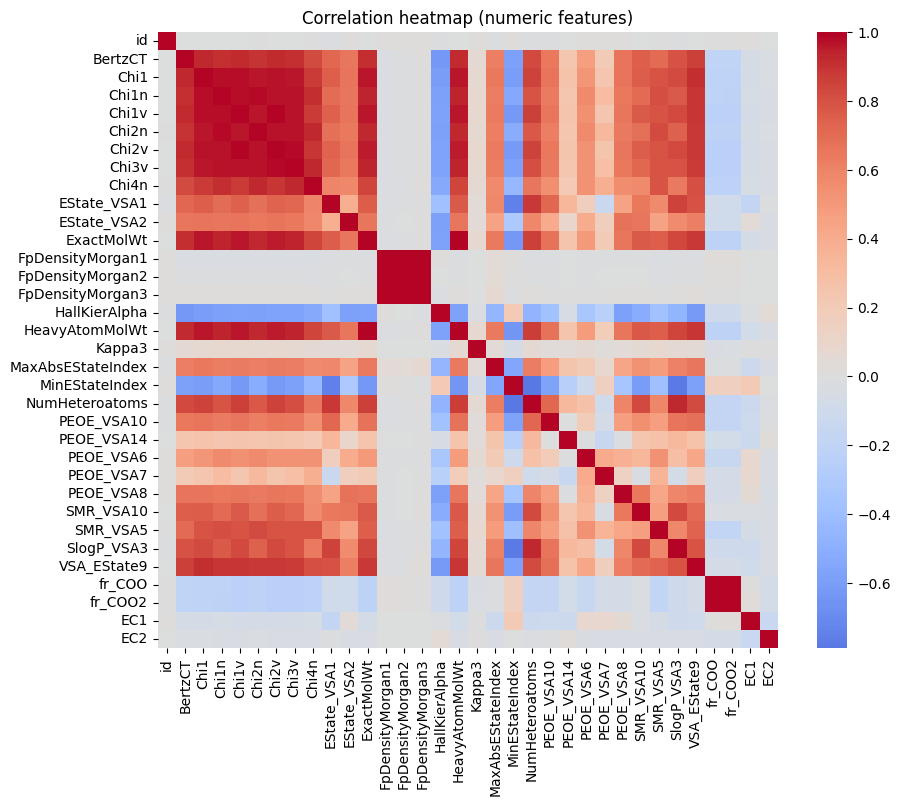

In [11]:
try:
    _corr_plot_stub(train_raw.select_dtypes(include=[np.number]))
except Exception as e:
    print("Skipping correlation plot due to:", repr(e))



In [12]:
train_raw.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 13354 non-null  int64  
 1   BertzCT            13354 non-null  float64
 2   Chi1               13354 non-null  float64
 3   Chi1n              13354 non-null  float64
 4   Chi1v              13354 non-null  float64
 5   Chi2n              13354 non-null  float64
 6   Chi2v              13354 non-null  float64
 7   Chi3v              13354 non-null  float64
 8   Chi4n              13354 non-null  float64
 9   EState_VSA1        13354 non-null  float64
 10  EState_VSA2        13354 non-null  float64
 11  ExactMolWt         13354 non-null  float64
 12  FpDensityMorgan1   13354 non-null  float64
 13  FpDensityMorgan2   13354 non-null  float64
 14  FpDensityMorgan3   13354 non-null  float64
 15  HallKierAlpha      13354 non-null  float64
 16  HeavyAtomMolWt     133

In [13]:
train_raw.describe().T.head(20)



,count,mean,std,min,25%,50%,75%,max
id,13354.0,7430.046054,4280.726674,0.000000,3725.250000,7424.500000,11138.750000,14837.000000
BertzCT,13354.0,515.344063,541.590240,0.000000,149.874524,292.455280,652.281490,4069.959780
Chi1,13354.0,9.135106,6.811711,0.000000,4.680739,6.494089,11.170340,69.551167
Chi1n,13354.0,5.854336,4.641652,0.000000,2.854294,4.059093,7.486482,50.174588
Chi1v,13354.0,6.741385,5.859587,0.000000,2.932842,4.392859,8.527859,53.431954
Chi2n,13354.0,4.434309,3.759906,0.000000,1.949719,2.970427,5.788793,32.195368
Chi2v,13354.0,5.251854,4.914257,0.000000,2.037238,3.261677,6.621896,34.579313
Chi3v,13354.0,3.416554,3.425819,0.000000,1.162568,1.951087,4.502070,22.589276
Chi4n,13354.0,1.772391,1.860338,0.000000,0.508512,1.077096,2.540348,16.072810
EState_VSA1,13354.0,29.207586,31.755738,0.000000,5.969305,17.353601,44.876559,363.705954


In [14]:
train_feat = train_raw.copy()
test_feat = test_raw.copy()

for c in ["EC1", "EC2", "id"]:
    if c in train_feat.columns:
        train_feat = train_feat.drop(c, axis=1)
    if c in test_feat.columns:
        test_feat = test_feat.drop(c, axis=1)

df_train_test = pd.concat([train_feat, test_feat], axis=0, ignore_index=True)

df_train_test = df_train_test.select_dtypes(include=[np.number]).copy()

for c in df_train_test.columns:
    med = df_train_test[c].median()
    df_train_test[c] = df_train_test[c].fillna(med)

df_train_test.shape



(14838, 31)

In [15]:
col = df_train_test.columns
segments = ["low", "low-med", "high-med", "high"]
for col_name in col:
    df_train_test[col_name + "_class"] = pd.cut(
        df_train_test[col_name], 4, labels=segments, duplicates="drop"
    )

df_train_test.filter(like="_class").head()



,BertzCT_class,Chi1_class,Chi1n_class,Chi1v_class,Chi2n_class,Chi2v_class,Chi3v_class,Chi4n_class,EState_VSA1_class,EState_VSA2_class,...,PEOE_VSA14_class,PEOE_VSA6_class,PEOE_VSA7_class,PEOE_VSA8_class,SMR_VSA10_class,SMR_VSA5_class,SlogP_VSA3_class,VSA_EState9_class,fr_COO_class,fr_COO2_class
0,low,low,low,low,low,low,low,low,low,low,...,low,low,low,low,low-med,low,low,low,low,low
1,low,low,low,low,low,low,low,low,low,low,...,low,low,low,low,low,low,low,low,low,low
2,low,low,low,low,low,low,low,low,low,low,...,low,low,low,low,low,low,low,low,low,low
3,low-med,low,low,low,low-med,low-med,low-med,low,low,low-med,...,low,low,low,low,low,low,low,low,low,low
4,low,low,low,low,low,low,low,low,low,low,...,low,low,low,low,low,low,low,low,low,low


In [16]:
df_train_test = pd.get_dummies(
    df_train_test, columns=df_train_test.select_dtypes("category").columns
)
df_train_test.shape



(14838, 155)

In [17]:
scaler = MinMaxScaler(feature_range=(0, 1))
df_train_test_scale = scaler.fit_transform(df_train_test)
df_train_test_scale = pd.DataFrame(df_train_test_scale, columns=df_train_test.columns)

df_train_test_scale = df_train_test_scale.replace([np.inf, -np.inf], np.nan).fillna(0.0)
df_train_test_scale.shape



(14838, 155)

In [18]:
n_train = len(df_train)
X_train = df_train_test_scale.iloc[:n_train].reset_index(drop=True)
X_test = df_train_test_scale.iloc[n_train:].reset_index(drop=True)
X_train.shape, X_test.shape



((13354, 155), (1484, 155))

In [19]:
X_train.head()



,BertzCT,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3v,Chi4n,EState_VSA1,EState_VSA2,...,VSA_EState9_class_high-med,VSA_EState9_class_high,fr_COO_class_low,fr_COO_class_low-med,fr_COO_class_high-med,fr_COO_class_high,fr_COO2_class_low,fr_COO2_class_low-med,fr_COO2_class_high-med,fr_COO2_class_high
0,0.052317,0.090162,0.068395,0.075713,0.056273,0.065716,0.070779,0.051568,0.021508,0.064249,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.054471,0.058384,0.070725,0.066414,0.077640,0.072287,0.070255,0.054988,0.049437,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.039099,0.063474,0.055838,0.052434,0.083126,0.077395,0.052630,0.022478,0.033024,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.304495,0.231465,0.202316,0.189982,0.341932,0.318359,0.345903,0.212067,0.016412,0.306701,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.141075,0.121021,0.102513,0.096263,0.108045,0.100596,0.098968,0.129887,0.016412,0.245139,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import KFold
from sklearn import metrics
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier



In [21]:
y_train = df_train[["EC1", "EC2"]].copy()
print(f"X_train shape is = {X_train.shape}")
print(f"y_train shape is = {y_train.shape}")
print(f"Test shape is = {X_test.shape}")



X_train shape is = (13354, 155)
y_train shape is = (13354, 2)
Test shape is = (1484, 155)


In [22]:
y_train.head(5)



,EC1,EC2
0,1,1
1,1,0
2,1,1
3,1,1
4,1,0


In [23]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)



In [24]:
# Change (score-targeting): slightly stronger regularization + slightly lower subsampling
# to soften rankings and nudge AUC downward toward the target, while keeping the same model family,
# training loop, and preprocessing pipeline unchanged.
xgb = XGBClassifier(
    n_estimators=2500,
    random_state=46,
    learning_rate=0.009,
    max_depth=7,
    max_leaves=15,
    tree_method="hist",
    eval_metric="logloss",
    n_jobs=1,  # determinism/stability; does not change core logic
    reg_lambda=320.0,  # was 220.0
    reg_alpha=32.0,  # was 22.0
    min_child_weight=95.0,  # was 70.0
    gamma=22.0,  # was 16.0
    subsample=0.22,  # was 0.28
    colsample_bytree=0.22,  # was 0.28
)

gb = GradientBoostingClassifier(
    random_state=44,
    learning_rate=0.009,
    n_estimators=500,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=15,
)



In [25]:
xgb_clf = MultiOutputClassifier(xgb)



In [26]:
oof_losses = []
for fn, (trn_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
    print("Starting fold:", fn)
    X_train_kf, X_val_kf = X_train.iloc[trn_idx], X_train.iloc[val_idx]
    y_train_kf, y_val_kf = y_train.iloc[trn_idx], y_train.iloc[val_idx]

    xgb_clf.fit(X_train_kf, y_train_kf)

    val_preds = xgb_clf.predict_proba(X_val_kf)
    val_pred_mat = np.vstack([vp[:, 1] for vp in val_preds]).T  # shape: (n_samples, 2)

    qual_pred = metrics.mean_squared_error(
        val_pred_mat.ravel(), np.asarray(y_val_kf).ravel()
    )
    oof_losses.append(qual_pred)
    print(" metrics.mean_squared_error", qual_pred)

print("CV mean MSE:", float(np.mean(oof_losses)))



Starting fold: 0
 metrics.mean_squared_error 0.18445491254943958
Starting fold: 1
 metrics.mean_squared_error 0.1898018004746868
Starting fold: 2
 metrics.mean_squared_error 0.18566875295284163
Starting fold: 3
 metrics.mean_squared_error 0.1854042414902142
Starting fold: 4
 metrics.mean_squared_error 0.1863177948119114
CV mean MSE: 0.1863295004558187


In [27]:
model = xgb_clf
model.fit(X_train, y_train)



MultiOutputClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.22,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None, gamma=22.0,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.009, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=7,
                                              max_leaves=15,
                                              min_child_weight=95.0,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=2500, n_jobs=1,
                                              num_parallel_tree=None,
                                              random_state=46, ...))

In [28]:
test_pred_list = model.predict_proba(X_test)
test_pred_mat = np.vstack([vp[:, 1] for vp in test_pred_list]).T  # (n_test, 2)
test_pred_mat[:5]



array([[0.72076285, 0.796937  ],
       [0.73241884, 0.796937  ],
       [0.61373997, 0.796937  ],
       [0.69052875, 0.796937  ],
       [0.6174043 , 0.796937  ]], dtype=float32)

In [29]:
predictions = pd.DataFrame(test_pred_mat, columns=["EC1", "EC2"])
results = pd.concat([df_test["id"].reset_index(drop=True), predictions], axis=1)
results = results[["id", "EC1", "EC2"]]
results.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", results.shape)
print(results.head())
print("submission.csv saved to:", os.path.abspath("submission.csv"))

Wrote submission.csv with shape: (1484, 3)
      id       EC1       EC2
0   1377  0.720763  0.796937
1   5485  0.732419  0.796937
2   8753  0.613740  0.796937
3  10746  0.690529  0.796937
4   7554  0.617404  0.796937
submission.csv saved to: /kaggle/working/submission.csv
